Dataset Loaded ✅
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')
['positive' 'negative']
0
['positive' 'negative']
review       0
sentiment    0
dtype: int64

Sentiment Count:
sentiment
0    24813
1    24799
Name: count, dtype: int64


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8675 - loss: 0.3111 - val_accuracy: 0.8907 - val_loss: 0.2640
Epoch 2/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9063 - loss: 0.2309 - val_accuracy: 0.8858 - val_loss: 0.2700
Epoch 3/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9300 - loss: 0.1760 - val_accuracy: 0.8824 - val_loss: 0.3056
Epoch 4/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9717 - loss: 0.0815 - val_accuracy: 0.8826 - val_loss: 0.3985
Epoch 5/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9947 - loss: 0.0201 - val_accuracy: 0.8792 - val_loss: 0.5648
Epoch 6/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 0.8788 - val_loss: 0.7486
Epoch 7/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9999 - loss: 7.0527e-04 - val_accuracy: 0.8782 - val_loss: 0.8853
Epoch 8/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 1.0000 

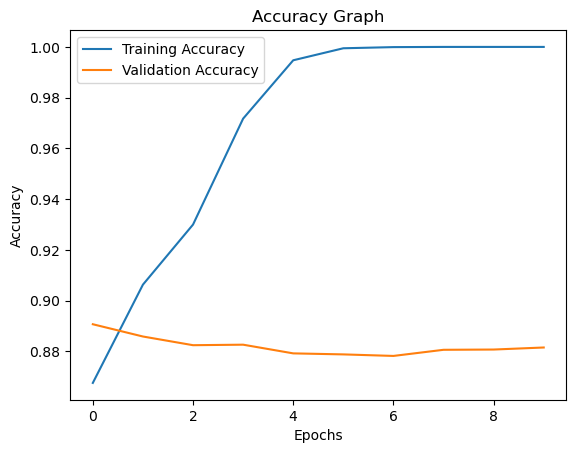

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 1.1360

Final Accuracy: 0.8814874291419983


In [2]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np                    # for numerical operations
import pandas as pd                   # for handling dataset (CSV)
import matplotlib.pyplot as plt       # for plotting graphs
import re                             # for text cleaning using regex

from sklearn.model_selection import train_test_split   # for splitting data
from sklearn.feature_extraction.text import TfidfVectorizer  # for text to numeric

from tensorflow.keras.models import Sequential         # for building NN model
from tensorflow.keras.layers import Dense              # for adding layers


# =========================
# 2. LOAD DATASET (SAFE)
# =========================
# Load CSV file safely (ignore errors if any bad lines)
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

print("Dataset Loaded ✅")
print(df.head())        # show first 5 rows
print(df.columns)       # show column names


# =========================
# 3. REMOVE NULL VALUES
# =========================
df = df.dropna()   # remove missing values

print(df['sentiment'].unique())   # check unique values
print(df['sentiment'].isnull().sum())  # check null values count

df = df.dropna()   # again ensure no null values


# =========================
# 4. VERIFY DATA
# =========================
print(df['sentiment'].unique())   # should be ['positive','negative']
print(df.isnull().sum())          # all values should be 0


# =========================
# 5. FIX COLUMN NAMES
# =========================
# Rename columns for consistency
df.columns = ['review', 'sentiment']


# =========================
# 6. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)                     # convert to string
    text = text.lower()                  # convert to lowercase
    text = re.sub(r'<.*?>', '', text)    # remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special characters/numbers
    return text

# Apply cleaning to all reviews
df['review'] = df['review'].apply(clean_text)


# =========================
# 7. CONVERT LABELS
# =========================
# Convert 'positive' → 1 and 'negative' → 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())   # check distribution


# =========================
# 8. TF-IDF VECTORIZATION
# =========================
# Convert text into numerical vectors
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review']).toarray()  # input features
y = df['sentiment']                                  # output labels


# =========================
# 9. TRAIN TEST SPLIT
# =========================
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 10. BUILD MODEL
# =========================
model = Sequential()   # create neural network model

# Input layer + hidden layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Output layer (1 neuron for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile model (define optimizer, loss, accuracy)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()   # display model structure


# =========================
# 11. TRAIN MODEL
# =========================
# Train the model using training data
history = model.fit(
    X_train, y_train,
    epochs=10,             # number of iterations
    batch_size=32,         # batch size
    validation_data=(X_test, y_test)  # validation
)


# =========================
# 12. PLOT GRAPH
# =========================
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# =========================
# 13. FINAL ACCURACY
# =========================
# Evaluate model performance on test data
loss, accuracy = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", accuracy)